**Name**: Umulkhair Abdinaser

**ID**: 227159

**Class**: 4C


# **1. Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
plt.style.use('ggplot')

# **2. Load dataset**

In [3]:
df = pd.read_csv("https://drive.google.com/uc?id=1klwIj4oQT43DWBVH5KWz0Z5BhcyGz-cR")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
cols_to_drop = ["Invoice ID", "Date", "Time", "gross income", "Tax 5%", "cogs", "gross margin percentage"]
df = df.drop(cols_to_drop, axis=1)

# **3. EDA (Correlation + Understanding)**

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Sales          1000 non-null   float64
 8   Payment        1000 non-null   object 
 9   Rating         1000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


,Unit price,Quantity,Sales,Rating
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,322.966749,6.97270
std,26.494628,2.923431,245.885335,1.71858
min,10.080000,1.000000,10.678500,4.00000
25%,32.875000,3.000000,124.422375,5.50000
50%,55.230000,5.000000,253.848000,7.00000
75%,77.935000,8.000000,471.350250,8.50000
max,99.960000,10.000000,1042.650000,10.00000


In [6]:
df.isnull().sum()

,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Sales,0
Payment,0
Rating,0


## **Correlation heatmap**

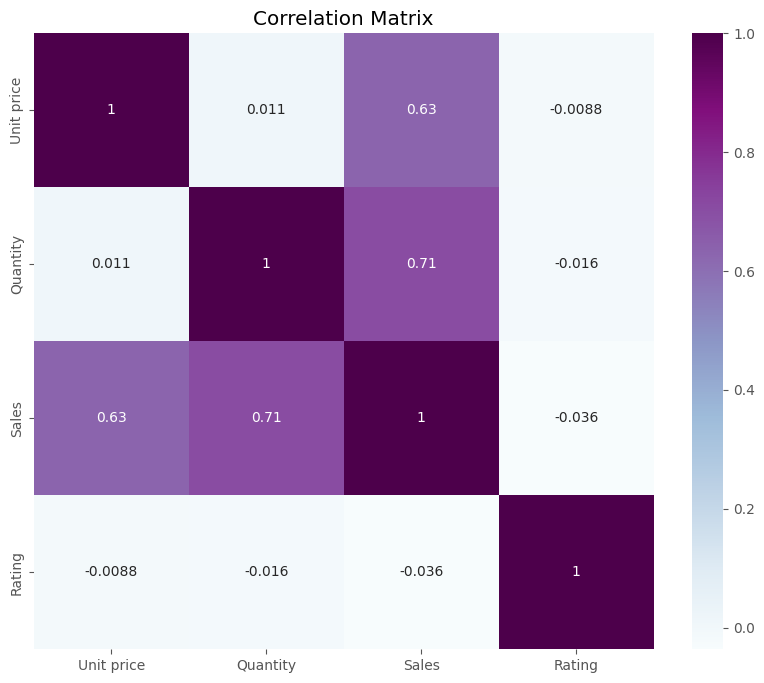

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="BuPu")
plt.title("Correlation Matrix")
plt.show()

## **Salesm distribution**

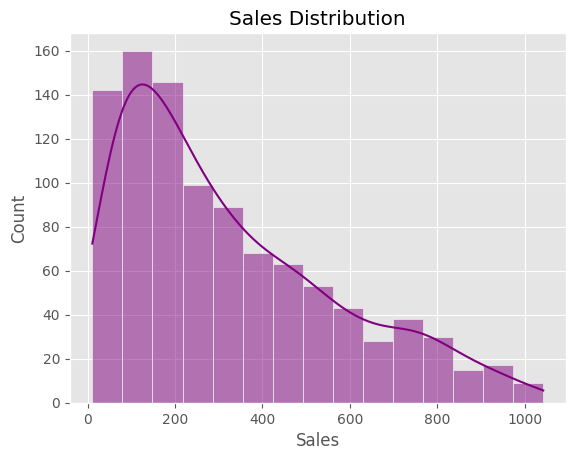

In [8]:
sns.histplot(df["Sales"], kde=True, color="purple")
plt.title("Sales Distribution")
plt.show()

# **4. Feature Engineering**

In [9]:
# Convert categorical text into dummy variables
df = pd.get_dummies(df, drop_first=True)



# **5. Split features and target**

In [10]:
X = df.drop('Sales', axis=1)
y = df['Sales']

# **6. Train/Test split (80/20)**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 16)
Test shape: (200, 16)


# **7. Scaling**

In [12]:
scaler = StandardScaler()
# Fit only on training data to prevent leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **8. Train model + Predict**

In [13]:
# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Calculate Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Cross-Validation to ensure the model is robust
cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

print(f"R2 Score: {r2:.4f}")
print(f"Cross-Validated R2: {cv_r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R2 Score: 0.9019
Cross-Validated R2: 0.8817
MAE: 59.38
RMSE: 79.90


# **9. Model Evaluation**

In [14]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance Metrics:")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Model Performance Metrics:
R2 Score: 0.9018802054495287
MAE: 59.38214157910874
RMSE: 79.89728615964347


# **10. Display Results**

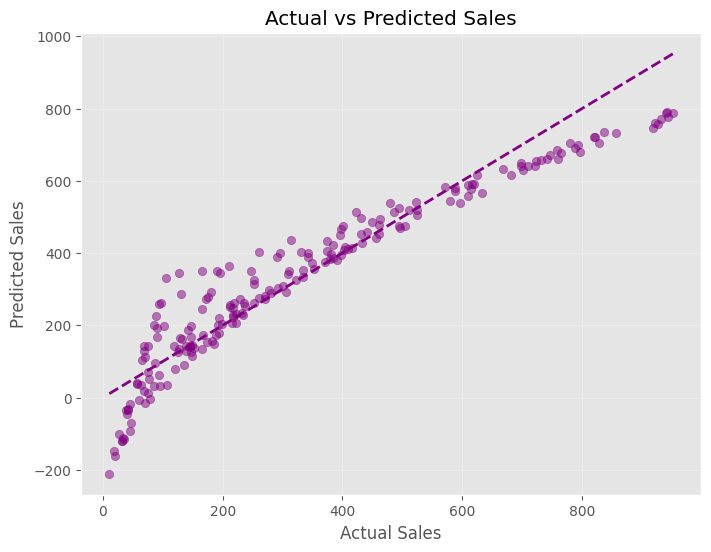

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5, color="purple")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="purple",
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.grid(True, alpha=0.3)
plt.show()

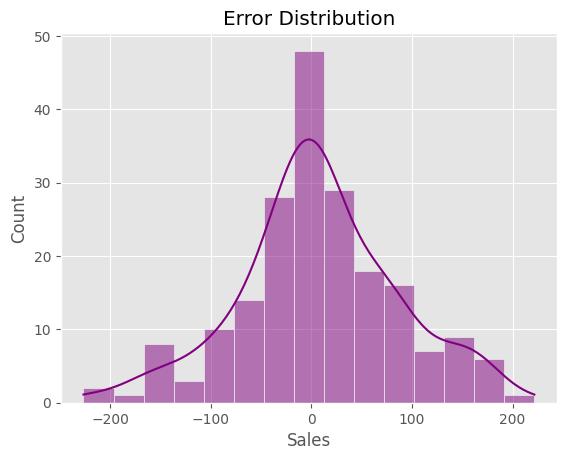

In [16]:
# Residuals
residuals = y_test - y_pred

sns.histplot(residuals, kde=True, color='purple')
plt.title("Error Distribution")
plt.show()